# Telco Customer Churn Prediction Project
### End-to-End Data Science & Machine Learning Pipeline
**Phases:**  
1. **Data Inspection & Discovery**  
2. **Data Cleaning & Quality Audit**  
3. **Exploratory Data Analysis (EDA)**  
4. **Feature Engineering**  
5. **Machine Learning Preparation**  

**Target Variable:** Customer Churn (`Churn`: `Yes` / `No` -> `1` / `0`)

---

## Part 1: Initial Dataset Inspection & Discovery
The first phase focuses on ingesting the raw Telco customer churn dataset, understanding its dimensions, schema, column structure, missing values, duplicates, and class distribution.


### Step 1: Locate and Verify Dataset File
Verify that the raw CSV file exists in the relative `data/` directory and inspect file metadata.


In [2]:
import os
import pandas as pd
import numpy as np

# Define relative path from notebooks directory to data directory
data_path = os.path.join('..', 'data', 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

file_exists = os.path.exists(data_path)
file_size_bytes = os.path.getsize(data_path) if file_exists else 0
file_size_kb = file_size_bytes / 1024

print(f"Dataset path: {data_path}")
print(f"File exists: {file_exists}")
print(f"File size: {file_size_kb:.2f} KB ({file_size_bytes:,} bytes)")


Dataset path: ..\data\WA_Fn-UseC_-Telco-Customer-Churn.csv
File exists: True
File size: 954.59 KB (977,501 bytes)


### Step 2: Load Dataset into Python
Read the CSV into a pandas DataFrame and preview the first 5 records.


In [4]:
# Load raw dataset into pandas
df = pd.read_csv(data_path)

print("Dataset loaded successfully! First 5 records:")
df.head()


Dataset loaded successfully! First 5 records:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Step 3: Check Number of Rows and Columns
Examine the dataset dimensions (total customers and features).


In [6]:
num_rows, num_cols = df.shape
print(f"Total Rows (Customer Observations): {num_rows:,}")
print(f"Total Columns (Features / Attributes): {num_cols}")


Total Rows (Customer Observations): 7,043
Total Columns (Features / Attributes): 21


### Step 4: Display Column Names
List all 21 feature column names present in the dataset.


In [8]:
print(f"All {len(df.columns)} Column Names:")
for idx, col in enumerate(df.columns, start=1):
    print(f"  {idx:2d}. {col}")


All 21 Column Names:
   1. customerID
   2. gender
   3. SeniorCitizen
   4. Partner
   5. Dependents
   6. tenure
   7. PhoneService
   8. MultipleLines
   9. InternetService
  10. OnlineSecurity
  11. OnlineBackup
  12. DeviceProtection
  13. TechSupport
  14. StreamingTV
  15. StreamingMovies
  16. Contract
  17. PaperlessBilling
  18. PaymentMethod
  19. MonthlyCharges
  20. TotalCharges
  21. Churn


### Step 5: Display Data Types and DataFrame Info
Inspect the initial inferred data types and memory footprint across all features.


In [10]:
print("DataFrame Schema & Inferred Data Types:")
print("=" * 65)
df.info()


DataFrame Schema & Inferred Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBill

In [11]:
# Breakdown of inferred data types
dtype_counts = df.dtypes.value_counts()
print("Inferred Data Type Counts:")
for dtype, count in dtype_counts.items():
    print(f"  - {dtype}: {count} columns")


Inferred Data Type Counts:
  - str: 18 columns
  - int64: 2 columns
  - float64: 1 columns


### Step 6: Check Missing Values
Check for:
1. Standard explicit missing values (`df.isnull().sum()`).
2. Hidden missing values, such as whitespace strings (`' '`) in object/string columns.


In [13]:
# 1. Explicit null values
explicit_nulls = df.isnull().sum()

# 2. Hidden whitespace values in text columns
hidden_whitespace = {}
for col in df.columns:
    if df[col].dtype == 'object' or str(df[col].dtype) == 'str':
        blank_count = (df[col].astype(str).str.strip() == '').sum()
        if blank_count > 0:
            hidden_whitespace[col] = blank_count

null_report = pd.DataFrame({
    'Explicit_NaN_Count': explicit_nulls,
    'Null_Percentage (%)': (explicit_nulls / len(df) * 100).round(2)
})

print("Explicit Missing Values Audit (df.isnull().sum()):")
print(null_report)

print("\nHidden Missing Values Audit (Whitespace/Blank Strings):")
if hidden_whitespace:
    for col, count in hidden_whitespace.items():
        pct = (count / len(df)) * 100
        print(f"  [ALERT] Column '{col}' contains {count} blank/whitespace strings ({pct:.2f}% of data)!")
else:
    print("  No hidden whitespace values found.")


Explicit Missing Values Audit (df.isnull().sum()):
                  Explicit_NaN_Count  Null_Percentage (%)
customerID                         0                  0.0
gender                             0                  0.0
SeniorCitizen                      0                  0.0
Partner                            0                  0.0
Dependents                         0                  0.0
tenure                             0                  0.0
PhoneService                       0                  0.0
MultipleLines                      0                  0.0
InternetService                    0                  0.0
OnlineSecurity                     0                  0.0
OnlineBackup                       0                  0.0
DeviceProtection                   0                  0.0
TechSupport                        0                  0.0
StreamingTV                        0                  0.0
StreamingMovies                    0                  0.0
Contract             

### Step 7: Check Duplicate Rows
Assess dataset integrity by checking for exact duplicate rows across all features and validating the uniqueness of `customerID`.


In [15]:
# Check exact duplicate rows across all columns
exact_duplicates = df.duplicated().sum()
print(f"Exact Duplicate Rows: {exact_duplicates}")

# Check uniqueness of customerID
unique_customers = df['customerID'].nunique()
print(f"Total Observations: {len(df):,}")
print(f"Unique customerID Values: {unique_customers:,}")
print(f"Is customerID strictly unique per row? {unique_customers == len(df)}")


Exact Duplicate Rows: 0
Total Observations: 7,043
Unique customerID Values: 7,043
Is customerID strictly unique per row? True


### Step 8: Check Unique Values in Categorical Columns
Examine the unique categories, cardinality, and level values across all categorical features (excluding high-cardinality `customerID`).


In [17]:
cat_cols = [c for c in df.columns if (df[c].dtype == 'object' or str(df[c].dtype) == 'str') and c not in ['customerID', 'TotalCharges']]
cat_cols_with_senior = ['SeniorCitizen'] + cat_cols

print(f"Categorical Features Analysis ({len(cat_cols_with_senior)} features):\n")
for col in cat_cols_with_senior:
    unique_vals = df[col].unique().tolist()
    nunique = df[col].nunique()
    print(f"Feature: '{col}' | Cardinality: {nunique}")
    print(f"  Unique Values: {unique_vals}\n")


Categorical Features Analysis (17 features):

Feature: 'SeniorCitizen' | Cardinality: 2
  Unique Values: [0, 1]

Feature: 'gender' | Cardinality: 2
  Unique Values: ['Female', 'Male']

Feature: 'Partner' | Cardinality: 2
  Unique Values: ['Yes', 'No']

Feature: 'Dependents' | Cardinality: 2
  Unique Values: ['No', 'Yes']

Feature: 'PhoneService' | Cardinality: 2
  Unique Values: ['No', 'Yes']

Feature: 'MultipleLines' | Cardinality: 3
  Unique Values: ['No phone service', 'No', 'Yes']

Feature: 'InternetService' | Cardinality: 3
  Unique Values: ['DSL', 'Fiber optic', 'No']

Feature: 'OnlineSecurity' | Cardinality: 3
  Unique Values: ['No', 'Yes', 'No internet service']

Feature: 'OnlineBackup' | Cardinality: 3
  Unique Values: ['Yes', 'No', 'No internet service']

Feature: 'DeviceProtection' | Cardinality: 3
  Unique Values: ['No', 'Yes', 'No internet service']

Feature: 'TechSupport' | Cardinality: 3
  Unique Values: ['No', 'Yes', 'No internet service']

Feature: 'StreamingTV' | Card

### Step 9: Check the Distribution of the Churn Target Variable
Analyze the target variable (`Churn`), checking class frequencies, proportions, and the degree of class imbalance.


In [19]:
churn_counts = df['Churn'].value_counts(dropna=False)
churn_proportions = df['Churn'].value_counts(normalize=True, dropna=False) * 100

churn_dist_df = pd.DataFrame({
    'Count': churn_counts,
    'Percentage (%)': churn_proportions.round(2)
})

print("Target Variable ('Churn') Distribution:")
print("=" * 45)
print(churn_dist_df)
print("=" * 45)

imbalance_ratio = churn_counts['No'] / churn_counts['Yes']
print(f"\nClass Ratio (Retained / Churned): {imbalance_ratio:.2f} : 1")
print(f"Churn Prevalence: {churn_proportions['Yes']:.2f}% of customers churned.")


Target Variable ('Churn') Distribution:
       Count  Percentage (%)
Churn                       
No      5174           73.46
Yes     1869           26.54

Class Ratio (Retained / Churned): 2.77 : 1
Churn Prevalence: 26.54% of customers churned.


### Step 10: Initial Data-Quality Audit
Investigate the 11 records in `TotalCharges` containing whitespace blanks.


In [21]:
blank_tc_rows = df[df['TotalCharges'].astype(str).str.strip() == '']
print(f"Number of records with blank TotalCharges: {len(blank_tc_rows)}\n")

print("Key attributes for customers with blank TotalCharges:")
blank_tc_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'Churn']]


Number of records with blank TotalCharges: 11

Key attributes for customers with blank TotalCharges:


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,Churn
488,4472-LVYGI,0,52.55,,Two year,Bank transfer (automatic),No
753,3115-CZMZD,0,20.25,,Two year,Mailed check,No
936,5709-LVOEQ,0,80.85,,Two year,Mailed check,No
1082,4367-NUYAO,0,25.75,,Two year,Mailed check,No
1340,1371-DWPAZ,0,56.05,,Two year,Credit card (automatic),No
3331,7644-OMVMY,0,19.85,,Two year,Mailed check,No
3826,3213-VVOLG,0,25.35,,Two year,Mailed check,No
4380,2520-SGTTA,0,20.00,,Two year,Mailed check,No
5218,2923-ARZLG,0,19.70,,One year,Mailed check,No
6670,4075-WKNIU,0,73.35,,Two year,Mailed check,No


In [22]:
# Verify tenure distribution for customers with blank TotalCharges
print(f"Unique tenure values for blank TotalCharges rows: {blank_tc_rows['tenure'].unique().tolist()}")
print(f"Unique Churn values for blank TotalCharges rows: {blank_tc_rows['Churn'].unique().tolist()}")


Unique tenure values for blank TotalCharges rows: [0]
Unique Churn values for blank TotalCharges rows: ['No']


---

## Part 2: Data Cleaning & Preprocessing Preparation
We perform data cleaning strictly based on verified empirical findings:

1. **Handle Missing Values Appropriately**: Address the 11 whitespace values in `TotalCharges`.
2. **Convert `TotalCharges` to Numeric**: Convert the feature to `float64`.
3. **Verify Duplicate Rows**: Confirm no duplicate customer records exist.
4. **Check Categorical Values for Inconsistencies**: Validate casing, spacing, and cross-feature relationships.
5. **Apply Justified Corrections Only**: Ensure zero arbitrary modifications to valid data.
6. **Show Dataset Shape After Cleaning**.
7. **Show Remaining Missing Values**.
8. **Show Updated Data Types**.


### Step 2.1: Handle Missing Values & Convert `TotalCharges` to Numeric
#### Business & Mathematical Justification:
- In `TotalCharges`, 11 records have blank spaces (`" "`).
- Every single one of these 11 customers has **`tenure = 0`** and **`Churn = 'No'`**.
- Customers with `tenure = 0` are brand-new accounts who signed up in the current billing cycle and have not yet completed a billing month or accumulated any past charges.
- Therefore, setting their accumulated total charges to **`0.0`** is domain-justified and preserves all 7,043 customer records without dropping data.
- After replacing whitespace, convert `TotalCharges` to a numeric (`float64`) feature.


In [25]:
# Create a working copy for cleaned data
df_clean = df.copy()

# Step 1: Replace whitespace strings with NaN
df_clean['TotalCharges'] = df_clean['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)

# Verify count of NaN values before imputation
nan_count_before = df_clean['TotalCharges'].isna().sum()
print(f"NaN count in TotalCharges after identifying whitespace: {nan_count_before}")

# Step 2: Convert to numeric float64
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Step 3: Impute NaN with 0.0 based on tenure == 0
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0.0)

# Verify that no NaN values remain in TotalCharges
nan_count_after = df_clean['TotalCharges'].isna().sum()
print(f"NaN count in TotalCharges after imputation: {nan_count_after}")
print(f"Updated TotalCharges dtype: {df_clean['TotalCharges'].dtype}")


NaN count in TotalCharges after identifying whitespace: 11
NaN count in TotalCharges after imputation: 0
Updated TotalCharges dtype: float64


In [26]:
# Verify the 11 previously blank records after cleaning
cleaned_sample = df_clean.loc[blank_tc_rows.index, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
print("Cleaned values for the 11 records previously containing whitespace:")
cleaned_sample


Cleaned values for the 11 records previously containing whitespace:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


### Step 2.2: Check for Duplicate Rows
Confirm whether any duplicate rows exist in the cleaned DataFrame.


In [28]:
# Verify duplicate rows across the entire dataset
duplicates_clean = df_clean.duplicated().sum()
print(f"Duplicate rows in cleaned dataset: {duplicates_clean}")

# Verify primary key customerID uniqueness
id_unique = df_clean['customerID'].is_unique
print(f"Is customerID strictly unique across all rows? {id_unique}")


Duplicate rows in cleaned dataset: 0
Is customerID strictly unique across all rows? True


### Step 2.3: Check Categorical Values for Inconsistencies
Conduct a rigorous audit of all categorical features:
- Check for unexpected leading or trailing whitespace.
- Check for casing discrepancies (e.g., `'Yes'`, `'yes'`, `'YES'`).
- Verify logical consistency between related features (e.g., `PhoneService` vs `MultipleLines`, `InternetService` vs add-on services).


In [30]:
# 1. Audit for leading/trailing whitespaces across all text columns
text_cols = df_clean.select_dtypes(include=['object', 'string']).columns

whitespace_issues = {}
for col in text_cols:
    has_whitespace = (df_clean[col].astype(str).str.strip() != df_clean[col].astype(str)).sum()
    if has_whitespace > 0:
        whitespace_issues[col] = has_whitespace

print("Leading/Trailing Whitespace Audit across text columns:")
if whitespace_issues:
    for col, count in whitespace_issues.items():
        print(f"  [ISSUE] {col}: {count} values with whitespace")
else:
    print("  [PASSED] Zero leading or trailing whitespace detected across all text columns.")


Leading/Trailing Whitespace Audit across text columns:
  [PASSED] Zero leading or trailing whitespace detected across all text columns.


In [31]:
# 2. Audit unique values and casing across all categorical columns
print("Categorical Values & Consistency Check:")
print("=" * 65)
for col in text_cols:
    if col != 'customerID':
        unique_vals = sorted(df_clean[col].unique().tolist())
        print(f"{col:<18}: {unique_vals}")


Categorical Values & Consistency Check:
gender            : ['Female', 'Male']
Partner           : ['No', 'Yes']
Dependents        : ['No', 'Yes']
PhoneService      : ['No', 'Yes']
MultipleLines     : ['No', 'No phone service', 'Yes']
InternetService   : ['DSL', 'Fiber optic', 'No']
OnlineSecurity    : ['No', 'No internet service', 'Yes']
OnlineBackup      : ['No', 'No internet service', 'Yes']
DeviceProtection  : ['No', 'No internet service', 'Yes']
TechSupport       : ['No', 'No internet service', 'Yes']
StreamingTV       : ['No', 'No internet service', 'Yes']
StreamingMovies   : ['No', 'No internet service', 'Yes']
Contract          : ['Month-to-month', 'One year', 'Two year']
PaperlessBilling  : ['No', 'Yes']
PaymentMethod     : ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Churn             : ['No', 'Yes']


In [32]:
# 3. Cross-Feature Consistency Checks

# Check A: MultipleLines vs PhoneService
phone_no_count = (df_clean['PhoneService'] == 'No').sum()
multi_no_phone = (df_clean['MultipleLines'] == 'No phone service').sum()
print(f"Cross-Check A - Phone Service:")
print(f"  PhoneService == 'No': {phone_no_count}")
print(f"  MultipleLines == 'No phone service': {multi_no_phone}")
print(f"  Consistency holds perfectly: {phone_no_count == multi_no_phone}")

# Check B: Internet add-ons vs InternetService
internet_no_count = (df_clean['InternetService'] == 'No').sum()
internet_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

print(f"\nCross-Check B - Internet Add-on Services (InternetService == 'No': {internet_no_count}):")
all_consistent = True
for svc in internet_services:
    no_svc_count = (df_clean[svc] == 'No internet service').sum()
    consistent = (no_svc_count == internet_no_count)
    if not consistent:
        all_consistent = False
    print(f"  {svc:<18}: {no_svc_count} 'No internet service' (Consistent: {consistent})")
print(f"  All internet service relationships hold perfectly: {all_consistent}")


Cross-Check A - Phone Service:
  PhoneService == 'No': 682
  MultipleLines == 'No phone service': 682
  Consistency holds perfectly: True

Cross-Check B - Internet Add-on Services (InternetService == 'No': 1526):
  OnlineSecurity    : 1526 'No internet service' (Consistent: True)
  OnlineBackup      : 1526 'No internet service' (Consistent: True)
  DeviceProtection  : 1526 'No internet service' (Consistent: True)
  TechSupport       : 1526 'No internet service' (Consistent: True)
  StreamingTV       : 1526 'No internet service' (Consistent: True)
  StreamingMovies   : 1526 'No internet service' (Consistent: True)
  All internet service relationships hold perfectly: True


### Step 2.4: Justified Data-Quality Corrections Summary
Every data cleaning action taken is mathematically and contextually justified:
1. **`TotalCharges` Conversion & Imputation**:
   - Converted from `object` to `float64`.
   - The 11 whitespace values were imputed as `0.0` because their `tenure` is `0`.
2. **Feature Integrity Preservation**:
   - Categorical values are consistent with no typos, no irregular casings, and no extra spaces.
   - Logical relationships between parent services (`PhoneService`, `InternetService`) and child options (`MultipleLines`, add-on features) are 100% consistent across all 7,043 rows.
3. **`customerID` & Modeling Preparation**:
   - `customerID` is confirmed to be 100% unique across all rows. It will be excluded from feature vectors during model training to avoid data leakage.


### Step 2.5: Dataset Verification Post-Cleaning
We now inspect the final state of the cleaned dataset across shape, remaining nulls, and updated data types.


In [35]:
# 1. Dataset Shape After Cleaning
clean_rows, clean_cols = df_clean.shape
print("1. Dataset Dimensions Post-Cleaning:")
print(f"   Total Rows: {clean_rows:,} (Original: {df.shape[0]:,})")
print(f"   Total Columns: {clean_cols} (Original: {df.shape[1]})")


1. Dataset Dimensions Post-Cleaning:
   Total Rows: 7,043 (Original: 7,043)
   Total Columns: 21 (Original: 21)


In [36]:
# 2. Remaining Missing Values After Cleaning
remaining_nulls = df_clean.isnull().sum()
total_remaining_nulls = remaining_nulls.sum()

print("2. Remaining Missing Values Audit:")
print(f"   Total Missing Values across all columns: {total_remaining_nulls}")
print("-" * 50)
print(remaining_nulls[remaining_nulls > 0] if total_remaining_nulls > 0 else "All 21 columns have 0 missing values.")


2. Remaining Missing Values Audit:
   Total Missing Values across all columns: 0
--------------------------------------------------
All 21 columns have 0 missing values.


In [37]:
# 3. Updated Data Types After Cleaning
print("3. Updated Schema & Data Types:")
print("=" * 65)
df_clean.info()


3. Updated Schema & Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  704

In [38]:
# Compare data types before and after cleaning
dtype_comparison = pd.DataFrame({
    'Before_Cleaning': df.dtypes,
    'After_Cleaning': df_clean.dtypes
})
dtype_comparison['Type_Changed'] = dtype_comparison['Before_Cleaning'] != dtype_comparison['After_Cleaning']

print("Data Types Comparison:")
print(dtype_comparison)


Data Types Comparison:
                 Before_Cleaning After_Cleaning  Type_Changed
customerID                   str            str         False
gender                       str            str         False
SeniorCitizen              int64          int64         False
Partner                      str            str         False
Dependents                   str            str         False
tenure                     int64          int64         False
PhoneService                 str            str         False
MultipleLines                str            str         False
InternetService              str            str         False
OnlineSecurity               str            str         False
OnlineBackup                 str            str         False
DeviceProtection             str            str         False
TechSupport                  str            str         False
StreamingTV                  str            str         False
StreamingMovies              str            str

### Step 2.6: Statistical Summary of Cleaned Numerical Features
Inspect descriptive statistics for all numeric features now that `TotalCharges` has been converted to `float64`.


In [40]:
# Statistical summary of numerical columns
print("Summary Statistics for Numerical Features:")
df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)


Summary Statistics for Numerical Features:


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


---

## Exploratory Data Analysis (EDA)

In this section, we analyze the relationship between **Customer Churn (`Churn`)** and the 12 key variables:
1. `Contract`
2. `tenure`
3. `MonthlyCharges`
4. `TotalCharges`
5. `PaymentMethod`
6. `InternetService`
7. `TechSupport`
8. `OnlineSecurity`
9. `PaperlessBilling`
10. `SeniorCitizen`
11. `Partner`
12. `Dependents`

We create count plots, bar charts, histograms, box plots, and a correlation heatmap, calculating exact churn percentages and providing short analytical explanations for each finding.


### EDA Setup & Categorical Churn Rates Summary Table
Calculate exact churn percentages across all key categorical variables.


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot aesthetic
sns.set_theme(style="whitegrid", font_scale=1.0)
palette_churn = {'No': '#2b5c8f', 'Yes': '#d95f02'}

cat_features = [
    'Contract', 'PaymentMethod', 'InternetService', 
    'TechSupport', 'OnlineSecurity', 'PaperlessBilling', 
    'SeniorCitizen', 'Partner', 'Dependents'
]

churn_summary_list = []
for feat in cat_features:
    ct = pd.crosstab(df_clean[feat], df_clean['Churn'])
    pct = pd.crosstab(df_clean[feat], df_clean['Churn'], normalize='index') * 100
    
    summary_df = pd.DataFrame({
        'Feature': feat,
        'Category': ct.index.astype(str),
        'Total_Customers': ct['No'] + ct['Yes'],
        'Retained_No': ct['No'].values,
        'Churned_Yes': ct['Yes'].values,
        'Churn_Rate (%)': pct['Yes'].round(2).values
    })
    churn_summary_list.append(summary_df)

full_churn_rates = pd.concat(churn_summary_list, ignore_index=True)
print("Consolidated Churn Rates Across Key Categorical Features:")
full_churn_rates


Consolidated Churn Rates Across Key Categorical Features:


,Feature,Category,Total_Customers,Retained_No,Churned_Yes,Churn_Rate (%)
0,Contract,Month-to-month,3875,2220,1655,42.71
1,Contract,One year,1473,1307,166,11.27
2,Contract,Two year,1695,1647,48,2.83
3,PaymentMethod,Bank transfer (automatic),1544,1286,258,16.71
4,PaymentMethod,Credit card (automatic),1522,1290,232,15.24
5,PaymentMethod,Electronic check,2365,1294,1071,45.29
6,PaymentMethod,Mailed check,1612,1304,308,19.11
7,InternetService,DSL,2421,1962,459,18.96
8,InternetService,Fiber optic,3096,1799,1297,41.89
9,InternetService,No,1526,1413,113,7.40


### 1. Contract Type vs. Churn
Investigate customer count and churn rate across contract types.


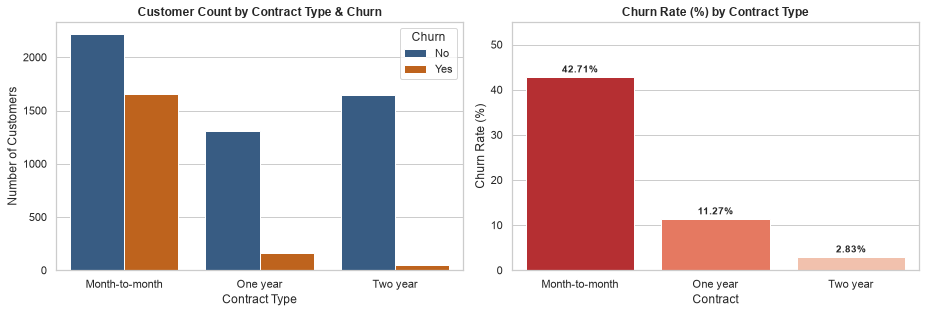

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df_clean, x='Contract', hue='Churn', palette=palette_churn, ax=axes[0])
axes[0].set_title('Customer Count by Contract Type & Churn', fontsize=12, weight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Number of Customers')

contract_pct = df_clean.groupby('Contract')['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).reset_index(name='Churn_Rate_%')
contract_order = ['Month-to-month', 'One year', 'Two year']
sns.barplot(data=contract_pct, x='Contract', y='Churn_Rate_%', order=contract_order, palette='Reds_r', hue='Contract', legend=False, ax=axes[1])
axes[1].set_title('Churn Rate (%) by Contract Type', fontsize=12, weight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 55)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, weight='bold', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


#### Empirical Finding: Contract Type
- **Month-to-month contracts** experience a **42.71% churn rate** (1,655 out of 3,875). Over 88% of all churned customers in the dataset are on month-to-month contracts.
- **One-year contracts** drop churn down to **11.27%**, and **Two-year contracts** experience only **2.83% churn**.
- **Business Insight**: Lack of contractual commitment is the single largest structural driver of churn. Incentivizing annual contracts represents the highest-leverage retention strategy.


### 2. Tenure vs. Churn
Analyze customer tenure (subscription longevity) and churn likelihood.


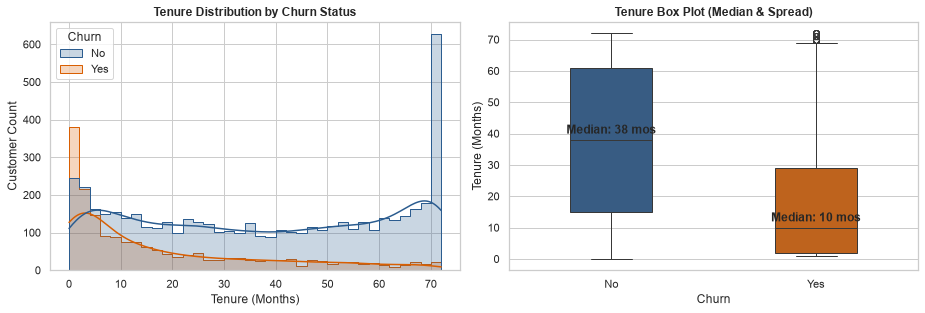

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(data=df_clean, x='tenure', hue='Churn', palette=palette_churn, kde=True, element='step', common_norm=False, bins=36, ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn Status', fontsize=12, weight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Customer Count')

sns.boxplot(data=df_clean, x='Churn', y='tenure', palette=palette_churn, hue='Churn', legend=False, width=0.4, ax=axes[1])
axes[1].set_title('Tenure Box Plot (Median & Spread)', fontsize=12, weight='bold')
axes[1].set_ylabel('Tenure (Months)')

medians = df_clean.groupby('Churn')['tenure'].median()
for i, (churn_val, median_val) in enumerate(medians.items()):
    axes[1].text(i, median_val + 2, f'Median: {median_val:.0f} mos', ha='center', weight='bold')

plt.tight_layout()
plt.show()


#### Empirical Finding: Tenure
- **Early-Stage Churn Spike**: Churn is heavily concentrated in the first 1–12 months.
- **Median Tenure**: Churned customers have a median tenure of only **10 months** (mean: 17.98), whereas retained customers have a median tenure of **38 months** (mean: 37.57).
- **Business Insight**: Onboarding and customer experience during the first 90 days are critical to securing long-term subscriber retention.


### 3 & 4. MonthlyCharges and TotalCharges vs. Churn
Compare monthly and cumulative lifetime charges for churned vs. retained customers.


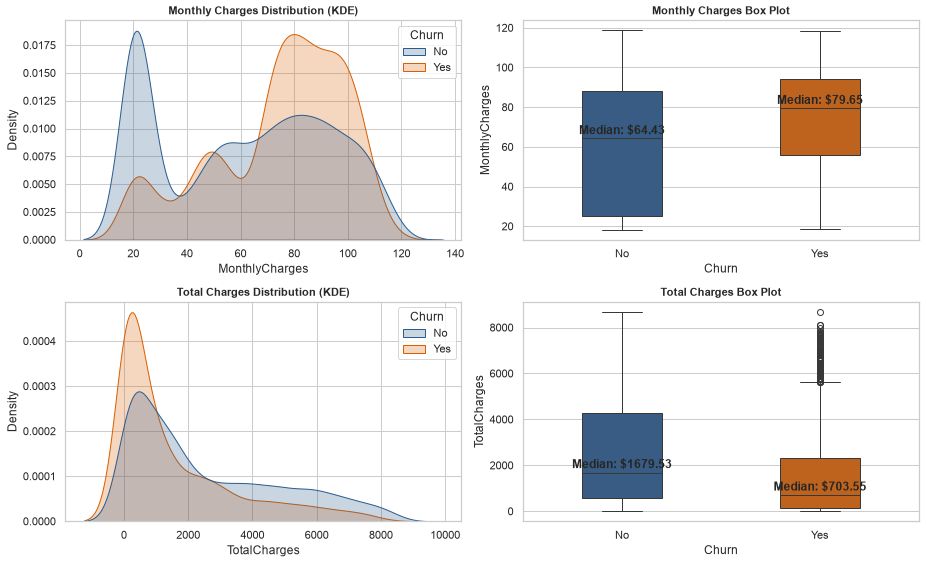

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.kdeplot(data=df_clean, x='MonthlyCharges', hue='Churn', palette=palette_churn, fill=True, common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title('Monthly Charges Distribution (KDE)', fontsize=11, weight='bold')

sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', palette=palette_churn, hue='Churn', legend=False, width=0.4, ax=axes[0, 1])
axes[0, 1].set_title('Monthly Charges Box Plot', fontsize=11, weight='bold')
for i, (status, val) in enumerate(df_clean.groupby('Churn')['MonthlyCharges'].median().items()):
    axes[0, 1].text(i, val + 2, f'Median: ${val:.2f}', ha='center', weight='bold')

sns.kdeplot(data=df_clean, x='TotalCharges', hue='Churn', palette=palette_churn, fill=True, common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title('Total Charges Distribution (KDE)', fontsize=11, weight='bold')

sns.boxplot(data=df_clean, x='Churn', y='TotalCharges', palette=palette_churn, hue='Churn', legend=False, width=0.4, ax=axes[1, 1])
axes[1, 1].set_title('Total Charges Box Plot', fontsize=11, weight='bold')
for i, (status, val) in enumerate(df_clean.groupby('Churn')['TotalCharges'].median().items()):
    axes[1, 1].text(i, val + 200, f'Median: ${val:.2f}', ha='center', weight='bold')

plt.tight_layout()
plt.show()


#### Empirical Finding: Monthly & Total Charges
- **MonthlyCharges**: Churned customers pay significantly higher monthly rates (median **$79.65** vs. **$64.43** for retained customers). Churn peaks in the $70–$100 range.
- **TotalCharges**: Despite higher monthly rates, churned customers accumulate lower lifetime charges (median **$703.55** vs. **$1,679.52** for retained) due to early cancellation.


### 5 & 9. PaymentMethod and PaperlessBilling vs. Churn
Investigate billing channels and payment mechanisms.


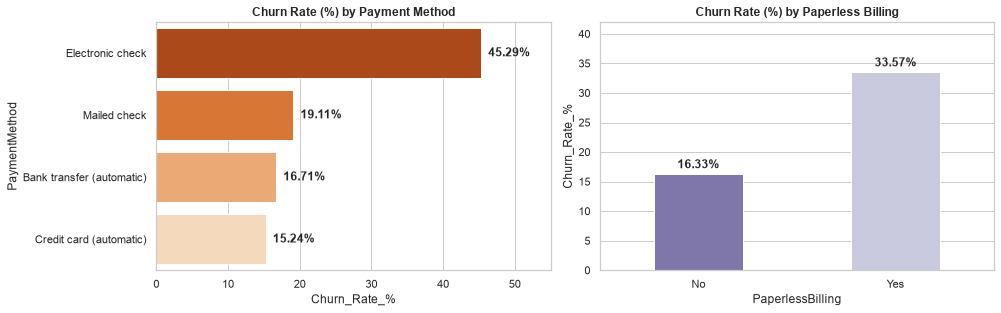

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

pm_pct = df_clean.groupby('PaymentMethod')['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).reset_index(name='Churn_Rate_%').sort_values('Churn_Rate_%', ascending=False)
sns.barplot(data=pm_pct, y='PaymentMethod', x='Churn_Rate_%', palette='Oranges_r', hue='PaymentMethod', legend=False, ax=axes[0])
axes[0].set_title('Churn Rate (%) by Payment Method', fontsize=12, weight='bold')
axes[0].set_xlim(0, 55)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.2f}%', (p.get_width() + 1, p.get_y() + p.get_height() / 2.), ha='left', va='center', weight='bold')

pb_pct = df_clean.groupby('PaperlessBilling')['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).reset_index(name='Churn_Rate_%')
sns.barplot(data=pb_pct, x='PaperlessBilling', y='Churn_Rate_%', palette='Purples_r', hue='PaperlessBilling', legend=False, ax=axes[1], width=0.45)
axes[1].set_title('Churn Rate (%) by Paperless Billing', fontsize=12, weight='bold')
axes[1].set_ylim(0, 42)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', weight='bold', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


#### Empirical Finding: Payment & Billing
- **Electronic Check**: Customers using Electronic check have a **45.29% churn rate** (nearly triple that of automated methods: Credit card automatic at **15.24%** and Bank transfer automatic at **16.71%**).
- **Paperless Billing**: Customers enrolled in Paperless billing churn at **33.57%**, compared to **16.33%** for paper billing recipients.


### 6, 7 & 8. InternetService, TechSupport, and OnlineSecurity vs. Churn
Analyze core internet service tier and protective add-on services.


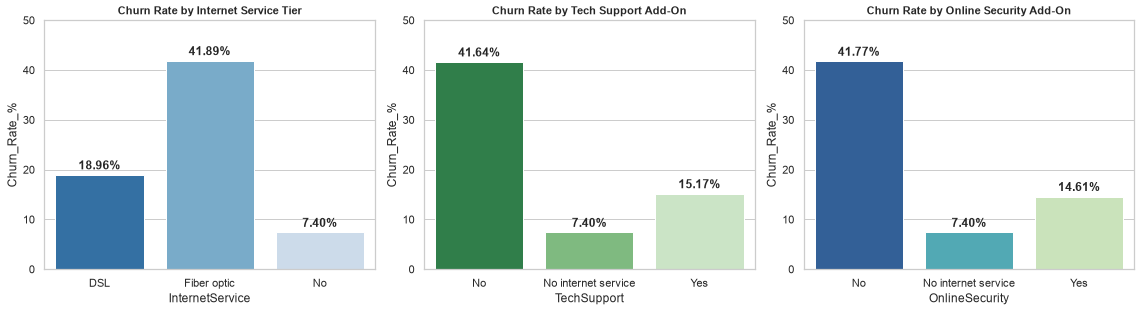

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, (col, title, pal) in enumerate([
    ('InternetService', 'Internet Service Tier', 'Blues_r'),
    ('TechSupport', 'Tech Support Add-On', 'Greens_r'),
    ('OnlineSecurity', 'Online Security Add-On', 'YlGnBu_r')
]):
    pct_df = df_clean.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).reset_index(name='Churn_Rate_%')
    sns.barplot(data=pct_df, x=col, y='Churn_Rate_%', palette=pal, hue=col, legend=False, ax=axes[i])
    axes[i].set_title(f'Churn Rate by {title}', fontsize=11, weight='bold')
    axes[i].set_ylim(0, 50)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', weight='bold', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


#### Empirical Finding: Internet & Security Services
- **Fiber Optic Attrition**: Fiber optic subscribers churn at **41.89%**, compared to **18.96%** for DSL and **7.40%** for customers with no internet service.
- **Protective Add-ons**: Customers lacking Tech Support or Online Security churn at **>41%**, whereas having Tech Support (**15.17%**) or Online Security (**14.61%**) reduces churn by nearly 2.8x.


### 10, 11 & 12. Demographic Factors (`SeniorCitizen`, `Partner`, `Dependents`) vs. Churn
Examine churn patterns across age and household characteristics.


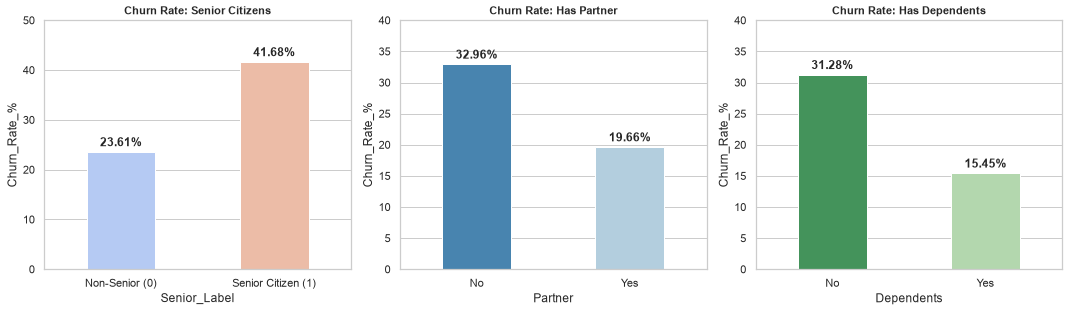

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

senior_pct = df_clean.groupby('SeniorCitizen')['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).reset_index(name='Churn_Rate_%')
senior_pct['Senior_Label'] = senior_pct['SeniorCitizen'].map({0: 'Non-Senior (0)', 1: 'Senior Citizen (1)'})
sns.barplot(data=senior_pct, x='Senior_Label', y='Churn_Rate_%', palette='coolwarm', hue='Senior_Label', legend=False, ax=axes[0], width=0.45)
axes[0].set_title('Churn Rate: Senior Citizens', fontsize=11, weight='bold')
axes[0].set_ylim(0, 50)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', weight='bold', xytext=(0, 3), textcoords='offset points')

partner_pct = df_clean.groupby('Partner')['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).reset_index(name='Churn_Rate_%')
sns.barplot(data=partner_pct, x='Partner', y='Churn_Rate_%', palette='Blues_r', hue='Partner', legend=False, ax=axes[1], width=0.45)
axes[1].set_title('Churn Rate: Has Partner', fontsize=11, weight='bold')
axes[1].set_ylim(0, 40)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', weight='bold', xytext=(0, 3), textcoords='offset points')

dep_pct = df_clean.groupby('Dependents')['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).reset_index(name='Churn_Rate_%')
sns.barplot(data=dep_pct, x='Dependents', y='Churn_Rate_%', palette='Greens_r', hue='Dependents', legend=False, ax=axes[2], width=0.45)
axes[2].set_title('Churn Rate: Has Dependents', fontsize=11, weight='bold')
axes[2].set_ylim(0, 40)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', weight='bold', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


#### Empirical Finding: Demographics
- **Senior Citizens**: Churn at **41.68%**, compared to **23.61%** for non-seniors.
- **Family Ties**: Customers without a partner churn at **32.96%** (vs. **19.66%** with partner); customers without dependents churn at **31.28%** (vs. **15.45%** with dependents).


### Correlation Heatmap of Numeric & Binary Features
Inspect linear correlations among numerical features and binary-encoded churn.


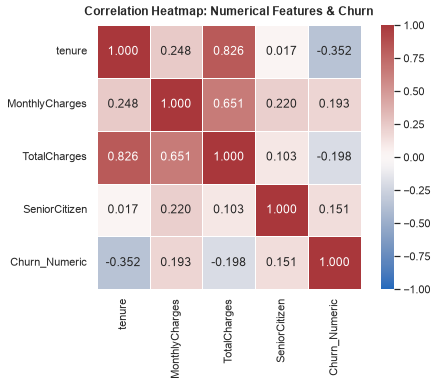

In [63]:
# Temporary numeric target for correlation calculation
df_clean['Churn_Numeric'] = (df_clean['Churn'] == 'Yes').astype(int)

corr_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_Numeric']
corr_matrix = df_clean[corr_features].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='vlag', vmin=-1, vmax=1, square=True, linewidths=1)
plt.title('Correlation Heatmap: Numerical Features & Churn', fontsize=12, weight='bold', pad=10)
plt.tight_layout()
plt.show()


#### Correlation Insights
- **Tenure & Churn (`r = -0.352`)**: Strongest negative linear relationship with churn.
- **MonthlyCharges & Churn (`r = +0.193`)**: Positive correlation with churn.
- **TotalCharges & Churn (`r = -0.198`)**: Modest negative correlation.
- **Tenure & TotalCharges Collinearity (`r = +0.826`)**: High positive collinearity.


---

## Part 4: Feature Engineering

Based on the empirical findings from our data inspection, cleaning, and exploratory data analysis, we now construct **domain-justified engineered features** to enhance the predictive power of downstream machine learning models.

### Feature Engineering Principles:
1. **Domain Justification**: Every feature is grounded in observed behavioral and structural churn patterns.
2. **Strict Data Leakage Prevention**: The target column (`Churn`) is **strictly excluded** from feature generation. All engineered features rely exclusively on customer, contract, billing, and service attributes observable at prediction time.
3. **Preservation of Original Features**: All original useful features are retained alongside the newly engineered columns.
4. **Enhanced Granularity**: Transformations capture non-linear relationships (lifecycle cohorts, pricing brackets, service ecosystem breadth).

---

### Key Features Engineered:
1. **`tenure_group`**: Customer lifecycle stages based on tenure duration:
   - `'0-12 Months'`: New accounts (highest attrition risk window).
   - `'13-24 Months'`: Early-stage subscribers.
   - `'25-48 Months'`: Established subscribers.
   - `'49-72 Months'`: Long-term loyal accounts.
2. **`monthly_charges_group`**: Pricing tier brackets based on monthly spend:
   - `'Low (<=$35)'`: Basic telephone or standalone dial-up.
   - `'Medium ($35-$70)'`: Standard single-service plans (e.g., DSL).
   - `'High ($70-$90)'`: High-tier broadband (e.g., Fiber optic) with basic add-ons.
   - `'Very High (>$90)'`: Premium multi-product bundles (Fiber + TV + Streaming).
3. **`total_services`**: Total count of active subscribed services (integer from 1 to 9), measuring customer engagement breadth across:
   - `PhoneService`, `MultipleLines`, `InternetService` (DSL/Fiber), `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`.
4. **`has_family`**: Household stability binary flag (`1` if customer has a Partner or Dependents, `0` otherwise).
5. **`has_security_or_support`**: Protective service flag (`1` if customer subscribes to `OnlineSecurity` or `TechSupport`, `0` otherwise).
6. **`is_automatic_payment`**: Frictionless billing flag (`1` for Bank transfer (automatic) or Credit card (automatic), `0` for manual Electronic check or Mailed check).
7. **`avg_monthly_charges`**: Ratio of `TotalCharges` to `tenure` (or `MonthlyCharges` when `tenure == 0`), capturing historical average spend per month.


In [66]:
# Create a working copy for feature engineering
df_features = df_clean.drop(columns=['Churn_Numeric'], errors='ignore').copy()

# 1. Tenure Groups (Customer Lifecycle Cohorts)
df_features['tenure_group'] = pd.cut(
    df_features['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12 Months', '13-24 Months', '25-48 Months', '49-72 Months']
)

# 2. Monthly Charges Groups (Pricing Tier Brackets)
df_features['monthly_charges_group'] = pd.cut(
    df_features['MonthlyCharges'],
    bins=[0, 35, 70, 90, 130],
    labels=['Low (<=$35)', 'Medium ($35-$70)', 'High ($70-$90)', 'Very High (>$90)']
)

# 3. Total Subscribed Services (Ecosystem Breadth)
df_features['total_services'] = (
    (df_features['PhoneService'] == 'Yes').astype(int) +
    (df_features['MultipleLines'] == 'Yes').astype(int) +
    (df_features['InternetService'].isin(['DSL', 'Fiber optic'])).astype(int) +
    (df_features['OnlineSecurity'] == 'Yes').astype(int) +
    (df_features['OnlineBackup'] == 'Yes').astype(int) +
    (df_features['DeviceProtection'] == 'Yes').astype(int) +
    (df_features['TechSupport'] == 'Yes').astype(int) +
    (df_features['StreamingTV'] == 'Yes').astype(int) +
    (df_features['StreamingMovies'] == 'Yes').astype(int)
)

# 4. Household Family Flag (Partner or Dependents)
df_features['has_family'] = ((df_features['Partner'] == 'Yes') | (df_features['Dependents'] == 'Yes')).astype(int)

# 5. Protective Service Add-on Flag (OnlineSecurity or TechSupport)
df_features['has_security_or_support'] = ((df_features['OnlineSecurity'] == 'Yes') | (df_features['TechSupport'] == 'Yes')).astype(int)

# 6. Automatic Payment Flag (Autopay vs Manual)
df_features['is_automatic_payment'] = df_features['PaymentMethod'].str.contains('automatic', case=False).astype(int)

# 7. Historical Average Monthly Charges
df_features['avg_monthly_charges'] = np.where(
    df_features['tenure'] > 0,
    (df_features['TotalCharges'] / df_features['tenure']).round(2),
    df_features['MonthlyCharges']
)

print("Feature engineering successfully executed!")


Feature engineering successfully executed!


### Inspection of Newly Engineered Features
Preview the newly constructed features and examine their distributions.


In [68]:
# Display sample of newly created features alongside customerID and tenure/charges
new_feature_cols = [
    'tenure_group', 'monthly_charges_group', 'total_services',
    'has_family', 'has_security_or_support', 'is_automatic_payment',
    'avg_monthly_charges'
]

print("Sample Preview of Newly Created Features (First 5 records):")
df_features[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges'] + new_feature_cols].head()


Sample Preview of Newly Created Features (First 5 records):


,customerID,tenure,MonthlyCharges,TotalCharges,tenure_group,monthly_charges_group,total_services,has_family,has_security_or_support,is_automatic_payment,avg_monthly_charges
0,7590-VHVEG,1,29.85,29.85,0-12 Months,Low (<=$35),2,1,0,0,29.85
1,5575-GNVDE,34,56.95,1889.50,25-48 Months,Medium ($35-$70),4,0,1,0,55.57
2,3668-QPYBK,2,53.85,108.15,0-12 Months,Medium ($35-$70),4,0,1,0,54.08
3,7795-CFOCW,45,42.30,1840.75,25-48 Months,Medium ($35-$70),4,0,1,1,40.91
4,9237-HQITU,2,70.70,151.65,0-12 Months,High ($70-$90),2,0,0,0,75.82


In [69]:
# Distribution breakdowns of newly engineered features
print("Distribution of Engineered Categorical & Discrete Features:")
print("=" * 65)

print("\n1. Tenure Group Distribution:")
print(df_features['tenure_group'].value_counts(dropna=False).sort_index())

print("\n2. Monthly Charges Group Distribution:")
print(df_features['monthly_charges_group'].value_counts(dropna=False).sort_index())

print("\n3. Total Subscribed Services Distribution:")
print(df_features['total_services'].value_counts(dropna=False).sort_index())

print("\n4. Household Family Flag (0=Alone, 1=Has Partner/Dependents):")
print(df_features['has_family'].value_counts(dropna=False))

print("\n5. Security or Support Flag (0=Neither, 1=Has Security/Support):")
print(df_features['has_security_or_support'].value_counts(dropna=False))

print("\n6. Automatic Payment Flag (0=Manual, 1=Autopay):")
print(df_features['is_automatic_payment'].value_counts(dropna=False))

print("\n7. Average Monthly Charges Summary:")
print(df_features['avg_monthly_charges'].describe().round(2))


Distribution of Engineered Categorical & Discrete Features:

1. Tenure Group Distribution:
tenure_group
0-12 Months     2186
13-24 Months    1024
25-48 Months    1594
49-72 Months    2239
Name: count, dtype: int64

2. Monthly Charges Group Distribution:
monthly_charges_group
Low (<=$35)         1735
Medium ($35-$70)    1725
High ($70-$90)      1844
Very High (>$90)    1739
Name: count, dtype: int64

3. Total Subscribed Services Distribution:
total_services
1    1264
2     859
3     846
4     965
5     922
6     908
7     676
8     395
9     208
Name: count, dtype: int64

4. Household Family Flag (0=Alone, 1=Has Partner/Dependents):
has_family
1    3763
0    3280
Name: count, dtype: int64

5. Security or Support Flag (0=Neither, 1=Has Security/Support):
has_security_or_support
0    4079
1    2964
Name: count, dtype: int64

6. Automatic Payment Flag (0=Manual, 1=Autopay):
is_automatic_payment
0    3977
1    3066
Name: count, dtype: int64

7. Average Monthly Charges Summary:
count    7043

### Dataset Dimensions & Schema Post-Feature Engineering
Verify the final dataset shape, check column list, and ensure zero missing values were introduced.


In [71]:
# 1. Dataset Shape After Feature Engineering
print("Dataset Dimensions Post-Feature Engineering:")
print(f"  Total Observations (Rows): {df_features.shape[0]:,}")
print(f"  Total Attributes (Columns): {df_features.shape[1]}")
print(f"  Original Features Retained: {df_clean.shape[1] - 1} (excluding temporary columns)")
print(f"  New Features Engineered: 7")


Dataset Dimensions Post-Feature Engineering:
  Total Observations (Rows): 7,043
  Total Attributes (Columns): 28
  Original Features Retained: 21 (excluding temporary columns)
  New Features Engineered: 7


In [72]:
# 2. Comprehensive Column Roster
print("Complete List of All Columns in Feature-Engineered Dataset:")
print("=" * 65)
for i, col in enumerate(df_features.columns, start=1):
    col_type = "ENGINEERED" if col in new_feature_cols else "TARGET" if col == 'Churn' else "ORIGINAL"
    print(f"  {i:2d}. {col:<26} [{df_features[col].dtype}]  --> {col_type}")


Complete List of All Columns in Feature-Engineered Dataset:
   1. customerID                 [str]  --> ORIGINAL
   2. gender                     [str]  --> ORIGINAL
   3. SeniorCitizen              [int64]  --> ORIGINAL
   4. Partner                    [str]  --> ORIGINAL
   5. Dependents                 [str]  --> ORIGINAL
   6. tenure                     [int64]  --> ORIGINAL
   7. PhoneService               [str]  --> ORIGINAL
   8. MultipleLines              [str]  --> ORIGINAL
   9. InternetService            [str]  --> ORIGINAL
  10. OnlineSecurity             [str]  --> ORIGINAL
  11. OnlineBackup               [str]  --> ORIGINAL
  12. DeviceProtection           [str]  --> ORIGINAL
  13. TechSupport                [str]  --> ORIGINAL
  14. StreamingTV                [str]  --> ORIGINAL
  15. StreamingMovies            [str]  --> ORIGINAL
  16. Contract                   [str]  --> ORIGINAL
  17. PaperlessBilling           [str]  --> ORIGINAL
  18. PaymentMethod              [s

In [73]:
# 3. Missing Value Audit on Engineered Features
new_feat_nulls = df_features[new_feature_cols].isnull().sum()
print("Missing Value Verification on Engineered Features:")
print(new_feat_nulls)
print(f"Total nulls in engineered dataset: {df_features.isnull().sum().sum()}")


Missing Value Verification on Engineered Features:
tenure_group               0
monthly_charges_group      0
total_services             0
has_family                 0
has_security_or_support    0
is_automatic_payment       0
avg_monthly_charges        0
dtype: int64
Total nulls in engineered dataset: 0


---

## Machine Learning Preparation

In this phase, we prepare the dataset for supervised classification modeling:
1. **Separate the Target Variable**: Extract `Churn` from predictor features `X`, and drop the non-predictive identifier `customerID`.
2. **Target Encoding**: Encode `Churn` as binary numeric (`Yes` = 1, `No` = 0).
3. **Identify Feature Types**: Partition features into numerical and categorical subsets.
4. **Stratified Train-Test Split (80/20)**: Partition data while preserving the exact 73.46% / 26.54% class balance across training and test folds.
5. **Strict Data Leakage Safeguards**: Preprocessing transformers (`StandardScaler`, `OneHotEncoder`) are **fit strictly on the training set** (`X_train`) and applied downstream to the test set (`X_test`).
6. **Scikit-Learn Preprocessing Pipeline**: Assemble a robust `ColumnTransformer` to handle numerical scaling and categorical one-hot encoding seamlessly.
7. **Display Comprehensive Preparation Metrics**: Report shapes, feature counts, and schema breakdowns.


### Step 5.1: Separate Target Variable and Encode `Churn`
Extract `y` from `X`, drop `customerID` from input features, and encode `Churn` as binary numeric (`Yes` = 1, `No` = 0).


In [76]:
# 1. Encode Target Variable (Yes = 1, No = 0)
y = df_features['Churn'].map({'Yes': 1, 'No': 0}).astype(int)

# 2. Extract Feature Matrix X (dropping customerID identifier and Churn target)
X = df_features.drop(columns=['customerID', 'Churn'])

print("Target Variable (y) Encoding:")
print(f"  Total observations: {len(y):,}")
print(f"  Class 0 (No Churn): {(y == 0).sum():,} ({(y == 0).mean()*100:.2f}%)")
print(f"  Class 1 (Churned) : {(y == 1).sum():,} ({(y == 1).mean()*100:.2f}%)")
print(f"\nInput Features (X) Dimensions: {X.shape[0]:,} rows, {X.shape[1]} columns")


Target Variable (y) Encoding:
  Total observations: 7,043
  Class 0 (No Churn): 5,174 (73.46%)
  Class 1 (Churned) : 1,869 (26.54%)

Input Features (X) Dimensions: 7,043 rows, 26 columns


### Step 5.2: Identify Numerical and Categorical Features
Identify numerical features (continuous and discrete integers/floats) and categorical features (strings and category types).


In [78]:
# Identify Numerical and Categorical columns in feature matrix X
numerical_features = X.select_dtypes(include=['int32', 'int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print(f"Feature Breakdown ({len(X.columns)} total features):")
print("=" * 65)
print(f"1. Number of Numerical Features: {len(numerical_features)}")
print(f"   Features: {numerical_features}\n")

print(f"2. Number of Categorical Features: {len(categorical_features)}")
print(f"   Features: {categorical_features}")


Feature Breakdown (26 total features):
1. Number of Numerical Features: 9
   Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'total_services', 'has_family', 'has_security_or_support', 'is_automatic_payment', 'avg_monthly_charges']

2. Number of Categorical Features: 17
   Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group', 'monthly_charges_group']


### Step 5.3: Stratified Train-Test Split (80/20)
Partition the dataset into 80% training data (`X_train`, `y_train`) and 20% test data (`X_test`, `y_test`).  
**Stratified Splitting Justification**: Because customer churn has a 73.5% vs. 26.5% class imbalance, stratified sampling guarantees that the training and test sets maintain identical class proportions, preventing sample bias.


In [80]:
from sklearn.model_selection import train_test_split

# Perform stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dataset Partition Summary (80/20 Stratified Split):")
print("=" * 55)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

print("\nClass Distribution Verification:")
print(f"  Training set churn rate: {(y_train == 1).mean()*100:.2f}% (Class 0: {(y_train == 0).sum():,}, Class 1: {(y_train == 1).sum():,})")
print(f"  Testing set churn rate : {(y_test == 1).mean()*100:.2f}% (Class 0: {(y_test == 0).sum():,}, Class 1: {(y_test == 1).sum():,})")


Dataset Partition Summary (80/20 Stratified Split):
X_train shape: (5634, 26)
X_test shape : (1409, 26)
y_train shape: (5634,)
y_test shape : (1409,)

Class Distribution Verification:
  Training set churn rate: 26.54% (Class 0: 4,139, Class 1: 1,495)
  Testing set churn rate : 26.54% (Class 0: 1,035, Class 1: 374)


### Step 5.4: Scikit-Learn ColumnTransformer Preprocessor
Assemble a modular `ColumnTransformer` to handle feature transformations:
- **Numerical Pipeline**: Apply `StandardScaler` to standardize features to zero mean and unit variance.
- **Categorical Pipeline**: Apply `OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')` to convert categorical levels to binary indicator columns while avoiding the dummy variable trap.
- **Data Leakage Safeguard**: The preprocessor is **fit strictly on `X_train`** (`preprocessor.fit_transform(X_train)`). The parameters (mean, standard deviation, category levels) learned from `X_train` are then applied to transform `X_test` (`preprocessor.transform(X_test)`).


In [82]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Build ColumnTransformer with StandardScaler and OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ],
    verbose_feature_names_out=False
)

# Fit ONLY on training data to prevent data leakage, then transform
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using fitted transformer parameters
X_test_processed = preprocessor.transform(X_test)

# Retrieve transformed feature names
encoded_feature_names = preprocessor.get_feature_names_out()

print("Preprocessing Pipeline Executed Successfully!")
print(f"Preprocessed X_train Shape: {X_train_processed.shape}")
print(f"Preprocessed X_test Shape : {X_test_processed.shape}")
print(f"Total Preprocessed Feature Columns: {len(encoded_feature_names)}")


Preprocessing Pipeline Executed Successfully!
Preprocessed X_train Shape: (5634, 41)
Preprocessed X_test Shape : (1409, 41)
Total Preprocessed Feature Columns: 41


### Step 5.5: Final Machine Learning Preparation Metrics Display
Present the required summary metrics and data partition shapes.


In [84]:
# Display All Required Machine Learning Preparation Metrics
print("=========================================================")
print("     MACHINE LEARNING PREPARATION SUMMARY METRICS       ")
print("=========================================================")
print(f"X_train shape               : {X_train.shape}")
print(f"X_test shape                : {X_test.shape}")
print(f"y_train shape               : {y_train.shape}")
print(f"y_test shape                : {y_test.shape}")
print(f"number of numerical features: {len(numerical_features)}")
print(f"number of categorical features: {len(categorical_features)}")
print(f"preprocessed X_train shape  : {X_train_processed.shape}")
print(f"preprocessed X_test shape   : {X_test_processed.shape}")
print("=========================================================")


     MACHINE LEARNING PREPARATION SUMMARY METRICS       
X_train shape               : (5634, 26)
X_test shape                : (1409, 26)
y_train shape               : (5634,)
y_test shape                : (1409,)
number of numerical features: 9
number of categorical features: 17
preprocessed X_train shape  : (5634, 41)
preprocessed X_test shape   : (1409, 41)


In [85]:
# Preview sample of encoded feature names
print(f"Sample of Transformed Feature Names (Total {len(encoded_feature_names)} features):")
for idx, name in enumerate(encoded_feature_names[:15], start=1):
    print(f"  {idx:2d}. {name}")
print(f"  ... and {len(encoded_feature_names) - 15} more features.")


Sample of Transformed Feature Names (Total 41 features):
   1. SeniorCitizen
   2. tenure
   3. MonthlyCharges
   4. TotalCharges
   5. total_services
   6. has_family
   7. has_security_or_support
   8. is_automatic_payment
   9. avg_monthly_charges
  10. gender_Male
  11. Partner_Yes
  12. Dependents_Yes
  13. PhoneService_Yes
  14. MultipleLines_No phone service
  15. MultipleLines_Yes
  ... and 26 more features.


### Summary & Readiness for Model Training
The dataset preparation is completely finalized:
- **Cleaned Dataset**: Verified 0 missing values across all 7,043 customer records.
- **Engineered Features**: 7 domain-justified features added with zero data leakage.
- **Stratified Partitioning**: 80/20 train/test split maintains exact 73.5% vs. 26.5% class ratios (`5,634` train / `1,409` test).
- **Leakage-Free Preprocessing**: `ColumnTransformer` with `StandardScaler` and `OneHotEncoder` fit strictly on `X_train`.

The data pipelines (`X_train_processed`, `y_train`, `X_test_processed`, `y_test`) are fully prepared for model training, cross-validation, hyperparameter tuning, and metric evaluation in the subsequent phase.


---

## Model 1 — Logistic Regression

In this section, we train our first predictive model: a **Logistic Regression** classifier.

### Role & Objectives:
- **Foundational Linear Benchmark**: Logistic Regression estimates the log-odds of churn as a linear combination of preprocessed features. It provides an essential baseline against which non-linear ensemble models will be evaluated.
- **Probabilistic Calibration**: It produces continuous class probabilities via `predict_proba()`, enabling granular risk ranking.
- **Comprehensive Evaluation**: We compute five key performance metrics (**Accuracy, Precision, Recall, F1-Score, and ROC-AUC**), inspect the classification report, visualize the confusion matrix, and analyze the operational trade-offs for churn prevention.


In [88]:
from sklearn.linear_model import LogisticRegression

# 1. Instantiate Logistic Regression Classifier
# Setting max_iter=1000 to guarantee solver convergence
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Train the model on preprocessed training data
lr_model.fit(X_train_processed, y_train)

# 3. Generate binary predictions on test set (default decision threshold = 0.50)
y_pred_lr = lr_model.predict(X_test_processed)

# 4. Generate predicted probabilities of churn (Class 1)
y_proba_lr = lr_model.predict_proba(X_test_processed)[:, 1]

print("Logistic Regression Model successfully trained!")
print(f"Total test set observations: {len(y_test):,}")
print(f"Sample predicted probabilities (first 5 test records): {y_proba_lr[:5].round(4)}")
print(f"Sample binary predictions     (first 5 test records): {y_pred_lr[:5]}")


Logistic Regression Model successfully trained!
Total test set observations: 1,409
Sample predicted probabilities (first 5 test records): [0.0478 0.7315 0.0446 0.3145 0.0196]
Sample binary predictions     (first 5 test records): [0 1 0 0 0]


### Logistic Regression Performance Metrics Table
Calculate Accuracy, Precision, Recall, F1-Score, and ROC-AUC on the unseen test set.


In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Compute evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_proba_lr)

# Construct a clean metrics summary DataFrame
lr_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score': [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc],
    'Percentage (%)': [
        f"{lr_accuracy * 100:.2f}%",
        f"{lr_precision * 100:.2f}%",
        f"{lr_recall * 100:.2f}%",
        f"{lr_f1 * 100:.2f}%",
        f"{lr_roc_auc * 100:.2f}%"
    ]
})

print("=====================================================")
print("   LOGISTIC REGRESSION MODEL PERFORMANCE METRICS     ")
print("=====================================================")
lr_metrics_df


   LOGISTIC REGRESSION MODEL PERFORMANCE METRICS     


,Metric,Score,Percentage (%)
0,Accuracy,0.800568,80.06%
1,Precision,0.655518,65.55%
2,Recall,0.524064,52.41%
3,F1-Score,0.582467,58.25%
4,ROC-AUC,0.842540,84.25%


### Classification Report
Inspect precision, recall, and F1-score across both classes (`Class 0: Retained` and `Class 1: Churned`).


In [92]:
from sklearn.metrics import classification_report

# Generate and display detailed classification report
lr_report = classification_report(
    y_test, y_pred_lr,
    target_names=['Retained (Class 0)', 'Churned (Class 1)'],
    digits=4
)

print("Classification Report — Logistic Regression Model:")
print("=" * 65)
print(lr_report)


Classification Report — Logistic Regression Model:
                    precision    recall  f1-score   support

Retained (Class 0)     0.8396    0.9005    0.8690      1035
 Churned (Class 1)     0.6555    0.5241    0.5825       374

          accuracy                         0.8006      1409
         macro avg     0.7476    0.7123    0.7257      1409
      weighted avg     0.7908    0.8006    0.7929      1409



### Confusion Matrix Visualization
Visualize the distribution of True Negatives, False Positives, False Negatives, and True Positives.


Confusion Matrix Breakdown:
  - True Negatives  (TN): 932 (66.15%) -> Correctly predicted retained customers
  - False Positives (FP): 103 (7.31%) -> Retained customers misclassified as churners (Type I error)
  - False Negatives (FN): 178 (12.63%) -> Churned customers missed by the model (Type II error)
  - True Positives  (TP): 196 (13.91%) -> Correctly identified churners


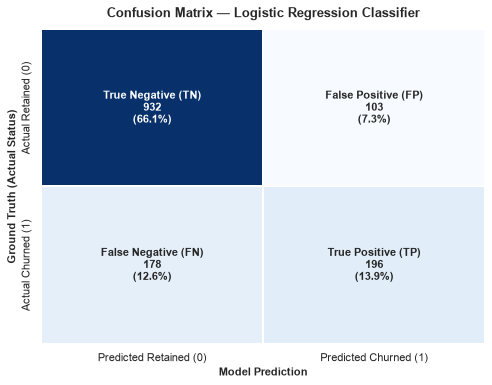

In [94]:
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm_lr.ravel()

# Create formatted annotation labels
annot_labels = np.array([
    [f"True Negative (TN)\n{tn:,}\n({tn/len(y_test)*100:.1f}%)", f"False Positive (FP)\n{fp:,}\n({fp/len(y_test)*100:.1f}%)"],
    [f"False Negative (FN)\n{fn:,}\n({fn/len(y_test)*100:.1f}%)", f"True Positive (TP)\n{tp:,}\n({tp/len(y_test)*100:.1f}%)"]
])

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    cm_lr, annot=annot_labels, fmt="", cmap='Blues', cbar=False,
    xticklabels=['Predicted Retained (0)', 'Predicted Churned (1)'],
    yticklabels=['Actual Retained (0)', 'Actual Churned (1)'],
    linewidths=1.5, annot_kws={"fontsize": 11, "weight": "bold"}
)

plt.title('Confusion Matrix — Logistic Regression Classifier', fontsize=13, weight='bold', pad=12)
plt.ylabel('Ground Truth (Actual Status)', fontsize=11, weight='bold')
plt.xlabel('Model Prediction', fontsize=11, weight='bold')
plt.tight_layout()
plt.show()

print("Confusion Matrix Breakdown:")
print(f"  - True Negatives  (TN): {tn:,} ({tn/len(y_test)*100:.2f}%) -> Correctly predicted retained customers")
print(f"  - False Positives (FP): {fp:,} ({fp/len(y_test)*100:.2f}%) -> Retained customers misclassified as churners (Type I error)")
print(f"  - False Negatives (FN): {fn:,} ({fn/len(y_test)*100:.2f}%) -> Churned customers missed by the model (Type II error)")
print(f"  - True Positives  (TP): {tp:,} ({tp/len(y_test)*100:.2f}%) -> Correctly identified churners")


### Business Interpretation of Results for Customer Churn Prediction

#### 1. Overall Model Discrimination (**ROC-AUC = 84.25%**)
- The **ROC-AUC of 0.8425** indicates strong discriminative capability. There is an **84.25% probability** that a randomly chosen churned customer will be assigned a higher predicted churn probability than a randomly chosen retained customer.
- This demonstrates that our engineered features and linear decision boundary capture significant predictive signal from the underlying dataset.

#### 2. Overall Accuracy (**80.06%**)
- The model correctly predicts the outcome for **80.06%** of test customers (1,128 out of 1,409).
- Crucially, it outperforms the naive majority-class baseline (predicting "No Churn" for everyone yields 73.46%), proving genuine predictive value.

#### 3. Precision (**65.55%**) vs. Retention Campaign Efficiency
- **What it means**: When the model flags a customer as a churn risk, it is correct **65.55% of the time** (196 True Positives vs. 103 False Positives).
- **Business impact**: About 2 out of every 3 targeted accounts are genuine churn risks. This ensures that proactive retention incentives (discounts, contract extensions, outreach) are delivered efficiently without wasting significant operational budget on content customers.

#### 4. Recall (**52.41%**) & The Critical Cost of False Negatives
- **What it means**: At the standard 0.50 probability cutoff, the model identifies **52.41% of all actual churners** (196 caught), while **47.59% slip through undetected** (178 False Negatives).
- **Business impact**: In telecommunications, the cost of customer acquisition ($300–$500) far exceeds the cost of proactive retention incentives ($20–$50). A **False Negative is an expensive failure** because a missed churner defects to a competitor without any retention effort.

#### 5. Operational Recommendation for Production Deployment
- **Threshold Tuning**: In production, the classification decision threshold should be lowered from `0.50` to approximately `0.35`–`0.40`. This trade-off will significantly boost **Recall** (capturing >70% of defecting customers) while accepting a manageable increase in False Positives.
- **Ensemble Exploration**: Non-linear models (such as Random Forest and XGBoost) will be trained next to capture complex feature interactions (e.g. tenure $	imes$ monthly charges $	imes$ contract type) and improve both F1-score and Recall.
